In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("../data/raw/interactions/2026-07-20/ratings.csv")
metadata = pd.read_csv("../data/raw/metadata/2026-07-20/movie_metadata.csv")

print(ratings.shape)
print(ratings.head())

(100000, 4)
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


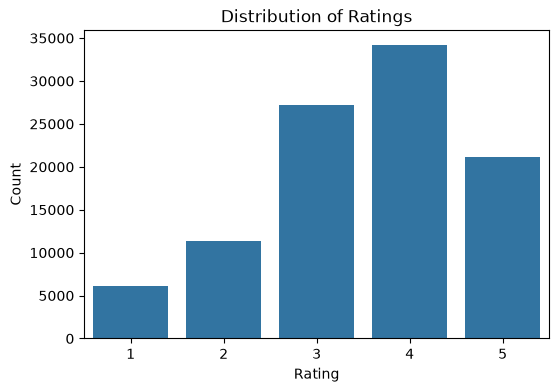

In [2]:
# Normalize timestamp into a readable date
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")

# Plot 1: Rating distribution
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=ratings)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

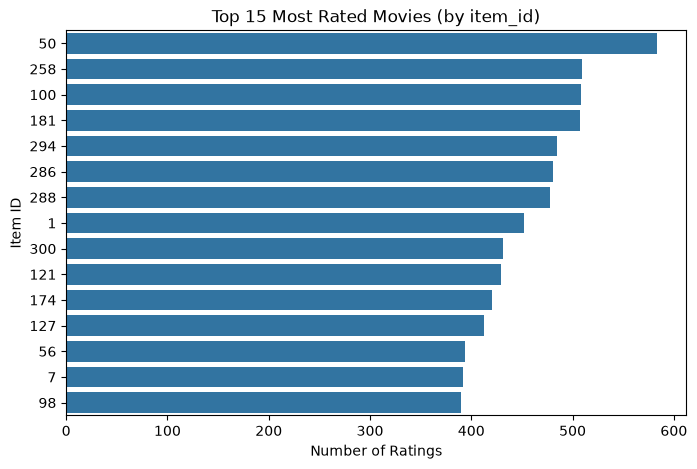

In [3]:
# Plot 2: Item popularity (top 15 most-rated movies)
item_counts = ratings["item_id"].value_counts().head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=item_counts.values, y=item_counts.index.astype(str))
plt.title("Top 15 Most Rated Movies (by item_id)")
plt.xlabel("Number of Ratings")
plt.ylabel("Item ID")
plt.show()

In [4]:
# Sparsity: what % of the user-item matrix is actually filled in?
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_items
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Users: {n_users}, Items: {n_items}")
print(f"Total possible user-item pairs: {possible_ratings}")
print(f"Actual ratings given: {n_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Users: 943, Items: 1682
Total possible user-item pairs: 1586126
Actual ratings given: 100000
Sparsity: 93.6953%


In [5]:
# Load user demographics and item genre data
u_cols = ["user_id", "age", "gender", "occupation", "zip_code"]
users = pd.read_csv("../data/raw/ml-100k/u.user", sep="|", names=u_cols)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_occupation = LabelEncoder()

users["gender_encoded"] = le_gender.fit_transform(users["gender"])
users["occupation_encoded"] = le_occupation.fit_transform(users["occupation"])

# Normalize age (0 to 1 scale)
users["age_normalized"] = (users["age"] - users["age"].min()) / (users["age"].max() - users["age"].min())

print(users.head())

   user_id  age gender  occupation zip_code  gender_encoded  \
0        1   24      M  technician    85711               1   
1        2   53      F       other    94043               0   
2        3   23      M      writer    32067               1   
3        4   24      M  technician    43537               1   
4        5   33      F       other    15213               0   

   occupation_encoded  age_normalized  
0                  19        0.257576  
1                  13        0.696970  
2                  20        0.242424  
3                  19        0.257576  
4                  13        0.393939  


In [6]:
# Merge ratings with user demographics
prepared = ratings.merge(users, on="user_id", how="left")

print(prepared.shape)
print(prepared.head())

# Save the prepared dataset -> this is the Task 5 deliverable
import os
os.makedirs("../data/processed", exist_ok=True)
prepared.to_csv("../data/processed/prepared_dataset.csv", index=False)
print("Saved prepared_dataset.csv")

(100000, 12)
   user_id  item_id  rating  timestamp                date  age gender  \
0      196      242       3  881250949 1997-12-04 15:55:49   49      M   
1      186      302       3  891717742 1998-04-04 19:22:22   39      F   
2       22      377       1  878887116 1997-11-07 07:18:36   25      M   
3      244       51       2  880606923 1997-11-27 05:02:03   28      M   
4      166      346       1  886397596 1998-02-02 05:33:16   47      M   

   occupation zip_code  gender_encoded  occupation_encoded  age_normalized  
0      writer    55105               1                  20        0.636364  
1   executive    00000               0                   6        0.484848  
2      writer    40206               1                  20        0.272727  
3  technician    80525               1                  19        0.318182  
4    educator    55113               1                   3        0.606061  
Saved prepared_dataset.csv


In [7]:
# User-level features
user_features = ratings.groupby("user_id").agg(
    user_activity_count=("rating", "count"),
    user_avg_rating=("rating", "mean")
).reset_index()

# Item-level features
item_features = ratings.groupby("item_id").agg(
    item_popularity=("rating", "count"),
    item_avg_rating=("rating", "mean")
).reset_index()

print(user_features.head())
print(item_features.head())

   user_id  user_activity_count  user_avg_rating
0        1                  272         3.610294
1        2                   62         3.709677
2        3                   54         2.796296
3        4                   24         4.333333
4        5                  175         2.874286
   item_id  item_popularity  item_avg_rating
0        1              452         3.878319
1        2              131         3.206107
2        3               90         3.033333
3        4              209         3.550239
4        5               86         3.302326


In [8]:
# Merge user and item features into the prepared dataset
feature_table = prepared.merge(user_features, on="user_id", how="left")
feature_table = feature_table.merge(item_features, on="item_id", how="left")

print(feature_table.shape)
print(feature_table.columns.tolist())

# Save as the final feature table
feature_table.to_csv("../data/processed/feature_table.csv", index=False)
print("Saved feature_table.csv")

(100000, 16)
['user_id', 'item_id', 'rating', 'timestamp', 'date', 'age', 'gender', 'occupation', 'zip_code', 'gender_encoded', 'occupation_encoded', 'age_normalized', 'user_activity_count', 'user_avg_rating', 'item_popularity', 'item_avg_rating']
Saved feature_table.csv
